# NAS search narrative -- how S12 dense was chosen

Curated, thesis-scoped report over `compression/results.csv`: seven stages,
each an explicit `config_name` allowlist (not a raw `stage`-column filter --
see `nas_stages.py`'s own docstring for why). Every plot uses the same house
style as `plot_forcedsp_lut70_alpha_sweep.py` (bold titles/labels, minimal
bordered legend, y-axis-only grid). Images are saved into `stage_1/`
.. `stage_7/` subfolders next to this notebook, plain filenames (no stage
number in the filename itself -- the folder already encodes it).

Stages 1-5 chart how S12 dense was chosen. Stages 6-7 are later,
post-selection probes run on top of that pick (does stage3 matter at
matched width; does width alone matter) -- not part of the original
selection decision, but built with the same allowlist/plotting machinery.

This is a curated, EXCLUDING report -- not every row in `results.csv` that
touches these architectures is shown here. Anything not carried forward to
the final pick (interleaving variants, separable-dense-dilation follow-ons,
quantization derivatives, etc.) is deliberately left out and documented in
the closing cell, not silently dropped.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import nas_stages as ns

REPORT_DIR = Path.cwd()
df = ns.load_results()


def show_table(stage_df: pd.DataFrame, extra_cols: list[str] | None = None) -> None:
    cols = ["label", "config_name", "dice", "params", "macs", "mem_elements"]
    if extra_cols:
        cols = cols[:2] + extra_cols + cols[2:]
    display(stage_df[[c for c in cols if c in stage_df.columns]])


def save(fig, stage_id: str, filename: str) -> None:
    out_dir = REPORT_DIR / stage_id
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=ns.SURFACE)
    print(f"Wrote {out_path}")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## Gap report

Run before anything else: which stage slots are actually populated in
`results.csv`, and which are known, deliberately-untrained gaps.


In [2]:
ns.report_gaps(df)

NAS narrative gap report

stage_0 -- ENet-paper-faithful origin point [OK: 2/2 present]

stage_1 -- Naive compression baseline [OK: 9/9 present]

stage_2 -- Single-op ablation at U4 [OK: 5/5 present]

stage_3 -- Context-block topology search under PReLU [OK: 7/7 present]
  EXCLUDED FROM THIS STAGE: S4.1 (4_1_e1_shape), S4.2 (4_2_extra_initial), S4.7 (4_5_double_projections), S4.8 (4_6_two_block_skip) -- these probe channel-shape/skip-connection axes, not context-block topology, so they don't belong in this comparison.

stage_4 -- dense_dilation sub-variant re-validation under ReLU [OK: 4/4 present]

stage_5 -- Hardware-legality revisit: decoder swap [OK: 3/3 present]
  EXCLUDED FROM THIS STAGE: nnUNetTrainerENet_12_dense_relu_nearest_conv_upsample_256 exists but uses context_pattern=dense_dilation_half (a distinct variant, not a decoder-only rerun of the Stage-4 winner) and belongs to the downstream 256-res hardware-build pipeline, not this controlled comparison.

stage_6 -- Post-selec

## Stage 1 -- Naive compression baseline

Uniform channel-width divisors of the ENet-paper baseline
(16,64,128,64,16): Original/U2/U4/U8/U16. All ReLU (`prelu=0`),
`upsample_conv` (bilinear) decoder, `context_pattern=default`. This curve
is the reference every later stage is compared against, and the source of
the "knee of the curve" argument for fixing later ablations at U4 (see the
Stage 2 section).

Alongside it, the ENet-paper-faithful PReLU + `max_unpool` companion curve
(same U2/U4/U8/U16 channel grid, anchored at Stage 0's full-width
`..._prelu_maxunpool_4c` point) is plotted on the same axes as its own
separate line -- the two curves use different decoders/activations and
aren't connected as one series.

,label,config_name,dice,params,macs,mem_elements
0,ENet Original,nnUNetTrainerENet_1_naive_baseline_Baseline,0.805767,365804.0,4.828627e+09,356352.0
1,U2,nnUNetTrainerENet_1_naive_baseline_U2,0.798824,93744.0,1.263731e+09,178944.0
2,U4,nnUNetTrainerENet_1_naive_baseline_U4,0.747088,24581.0,3.439985e+08,90240.0
3,U8,nnUNetTrainerENet_1_naive_baseline_U8,0.655512,6841.0,1.163919e+08,47168.0
4,U16,nnUNetTrainerENet_1_naive_baseline_U16,0.375356,2120.0,5.537792e+07,25632.0
5,U2 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.787844,95688.0,5.538447e+08,178944.0
6,U4 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.590484,25553.0,1.496842e+08,90240.0
7,U8 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.501847,7329.0,5.609882e+07,47168.0
8,U16 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.331299,2366.0,3.230925e+07,25632.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_1\dice_vs_params.png


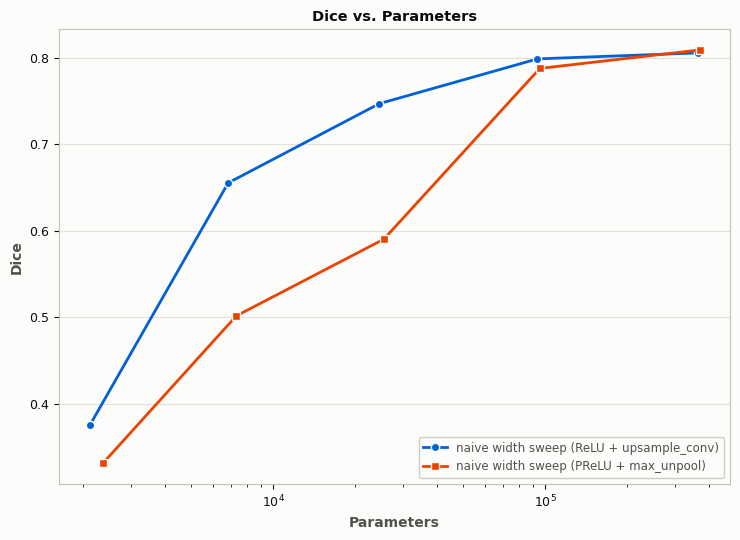

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_1\dice_vs_macs.png


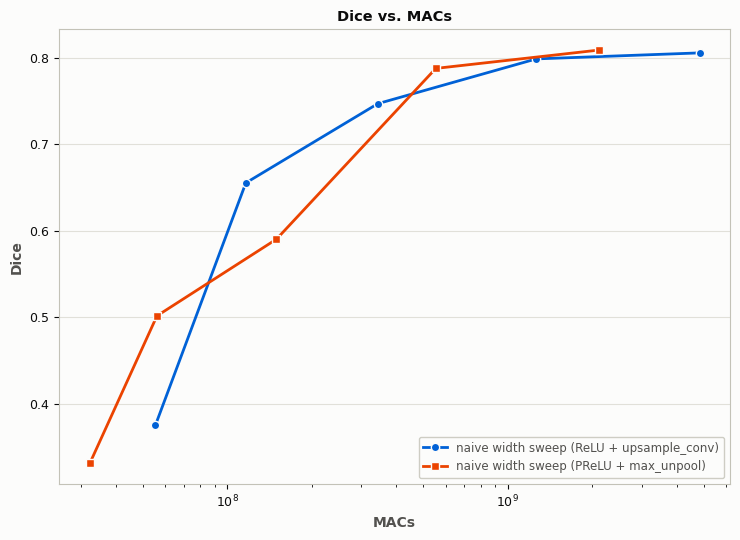

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_1\dice_vs_mem_elements.png


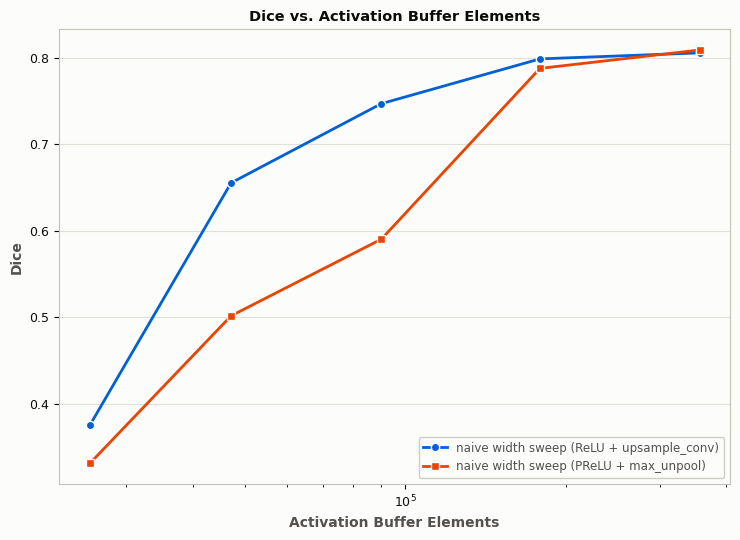

In [3]:
stage1 = ns.harvest("stage_1", df)
show_table(stage1)

RELU_NAMES = {
    "nnUNetTrainerENet_1_naive_baseline_Baseline",
    "nnUNetTrainerENet_1_naive_baseline_U2",
    "nnUNetTrainerENet_1_naive_baseline_U4",
    "nnUNetTrainerENet_1_naive_baseline_U8",
    "nnUNetTrainerENet_1_naive_baseline_U16",
}
stage1_relu = stage1[stage1["config_name"].isin(RELU_NAMES)]

prelu_anchor = df[df["config_name"] == "nnUNetTrainerENet_enet_original_prelu_maxunpool_4c"].copy()
prelu_anchor["label"] = "ENet Original (Stage 0 anchor)"
stage1_prelu = pd.concat(
    [prelu_anchor, stage1[~stage1["config_name"].isin(RELU_NAMES)]], ignore_index=True
)

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    s = stage1_relu.sort_values(metric)
    ax.plot(s[metric], s["dice"], color=ns.NAIVE_COLOR, linewidth=2, marker="o",
            markersize=6, markeredgecolor=ns.SURFACE, markeredgewidth=1, zorder=3,
            label="naive width sweep (ReLU + upsample_conv)")
    sp = stage1_prelu.sort_values(metric)
    ax.plot(sp[metric], sp["dice"], color=ns.SERIES_COLORS[2], linewidth=2, marker="s",
            markersize=6, markeredgecolor=ns.SURFACE, markeredgewidth=1, zorder=3,
            label="naive width sweep (PReLU + max_unpool)")
    ns.style_title_and_labels(ax, f"Dice vs. {xlabel}", xlabel)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_1", f"dice_vs_{metric}.png")
    plt.show()


## Stage 2 -- Single-op ablation at U4

Why U4: it sits at a favorable compute/discriminability point on Stage 1's
own curve (Table above) -- narrow enough for tractable iteration across the
full ablation grid that follows, wide enough (dice=0.747, still far from the
U8/U16 near-collapse regime) that an architectural delta is attributable to
the change, not to training noise.

Each probe flips exactly one flag off the U4 row (`dilated=1,asymmetric=1,
strided=1,dsc=0,context_pattern=default,prelu=0`): PReLU on, `max_unpool`
decoder, dilation off, asymmetric-factorization off. PReLU wins and is
carried forward into Stage 3; dilation is confirmed important (removing it
collapses dice); asymmetric factorization is confirmed unimportant (removing
it barely moves dice) and is dropped going forward -- this is why Stage 3's
probes all show `asymmetric=0`.


,label,config_name,dice,params,macs,mem_elements
0,U4 (reference),nnUNetTrainerENet_1_naive_baseline_U4,0.747088,24581.0,343998464.0,90240.0
1,+PReLU,nnUNetTrainerENet_2_special_ops_prelu,0.774265,25553.0,350093312.0,90240.0
2,+max_unpool,nnUNetTrainerENet_2_special_ops_maxunpool,0.592947,24581.0,343998464.0,90240.0
3,-dilation,nnUNetTrainerENet_2_special_ops_no_dilated,0.398633,24581.0,343998464.0,36992.0
4,-asymmetric,nnUNetTrainerENet_2_special_ops_no_asymmetric,0.754969,24261.0,337707008.0,86016.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_2\ops_ablation.png


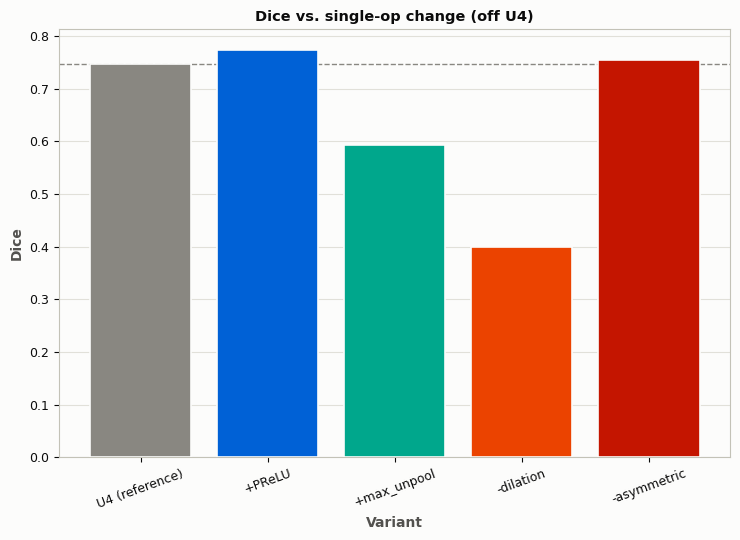

In [4]:
stage2 = ns.harvest("stage_2", df)
show_table(stage2)

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
ns.style_axes(ax)
colors = [ns.MUTED] + ns.SERIES_COLORS[: len(stage2) - 1]
ax.bar(stage2["label"], stage2["dice"], color=colors, edgecolor=ns.SURFACE, linewidth=1.2, zorder=3)
ref_dice = stage2.loc[stage2["config_name"] == "nnUNetTrainerENet_1_naive_baseline_U4", "dice"].iloc[0]
ax.axhline(ref_dice, color=ns.MUTED, linestyle="--", linewidth=1, zorder=2)
ns.style_title_and_labels(ax, "Dice vs. single-op change (off U4)", "Variant")
ax.tick_params(axis="x", labelrotation=20)
fig.tight_layout()
save(fig, "stage_2", "ops_ablation.png")
plt.show()


## Stage 3 -- Context-block topology search under PReLU

Curated 7-of-11 subset of raw stage `4_arch_probes`: only the probes that
vary the dilated context block's internal topology, all inheriting PReLU
from Stage 2's winner. **dense_dilation wins.**

Excluded from this comparison (different axis entirely, not context-block
topology -- footnoted, not plotted): S4.1 `e1_shape`, S4.2 `extra_initial`,
S4.7 `double_projections`, S4.8 `two_block_skip`.


,label,config_name,dice,params,macs,mem_elements
0,shallow dilation,nnUNetTrainerENet_4_4_1_shallow_dilation,0.750708,25201.0,343277568.0,132096.0
1,separable dilated,nnUNetTrainerENet_4_4_2_separable_dilated,0.761512,23857.0,323354624.0,86976.0
2,merge dilated pairs,nnUNetTrainerENet_4_4_3_merge_dilated_pairs,0.756661,20145.0,206700544.0,86016.0
3,DSC dilated-only,nnUNetTrainerENet_4_4_4_dsc_dilated_only,0.753173,21681.0,285605888.0,86016.0
4,DSC no-projection,nnUNetTrainerENet_4_7_dsc_no_projection,0.778492,30488.0,224788480.0,314880.0
5,dense dilation,nnUNetTrainerENet_4_8_dense_dilation,0.795975,25201.0,343277568.0,139264.0
6,shallow dilation (wide),nnUNetTrainerENet_4_9_shallow_dilation_wide,0.766738,25201.0,343277568.0,181248.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_3\dice_vs_params.png


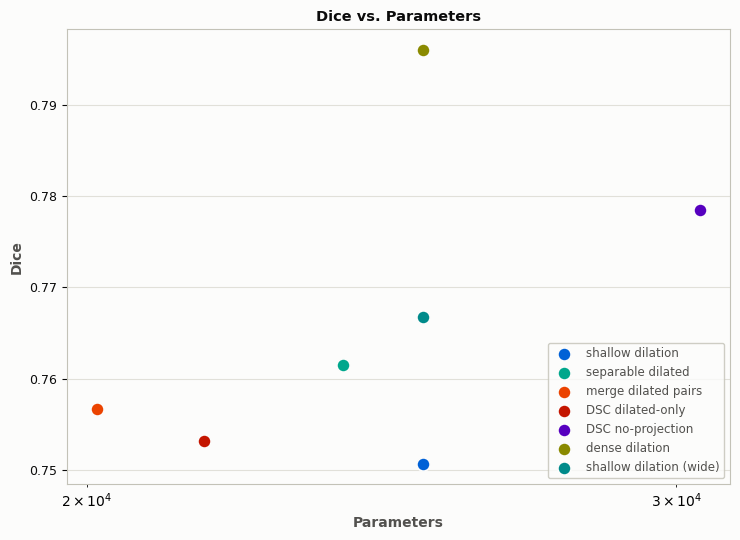

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_3\dice_vs_macs.png


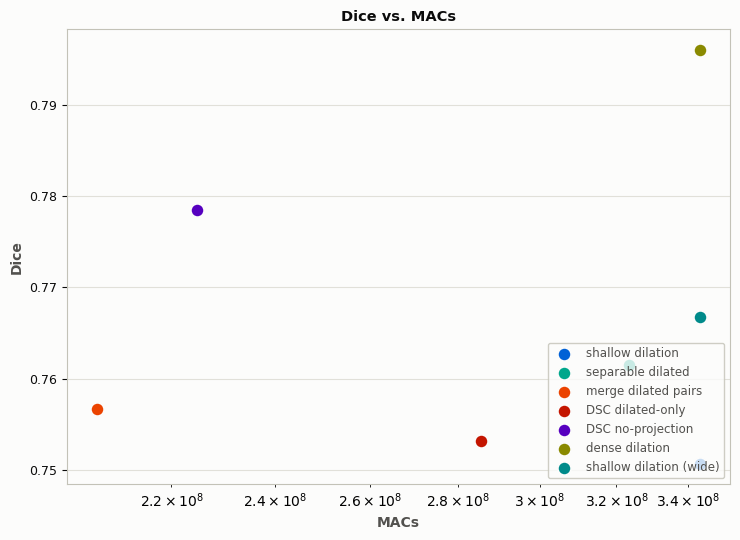

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_3\dice_vs_mem_elements.png


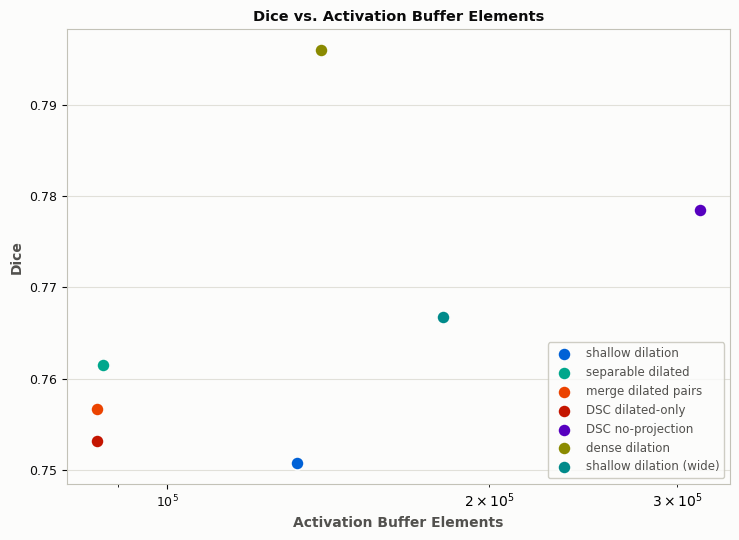

In [5]:
stage3 = ns.harvest("stage_3", df)
show_table(stage3)

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    for i, (_, row) in enumerate(stage3.iterrows()):
        color = ns.SERIES_COLORS[i % len(ns.SERIES_COLORS)]
        ax.scatter([row[metric]], [row["dice"]], color=color, s=90, zorder=4,
                   edgecolor=ns.SURFACE, linewidth=1.2, label=row["label"])
    ns.style_title_and_labels(ax, f"Dice vs. {xlabel}", xlabel)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_3", f"dice_vs_{metric}.png")
    plt.show()


## Stage 4 -- dense_dilation sub-variant re-validation under ReLU

FINN cannot fold per-channel PReLU into `MultiThreshold`. Stage 3's winning
topology (dense_dilation) is re-checked under ReLU across its own
sub-variants: plain dense, separable-dilated, DSC no-projection, DSC
projected. **Plain dense_dilation (S12 dense) is Pareto-optimal in params,
MACs, and activation buffer memory simultaneously** -- DSC no-projection is
competitive on params/MACs alone but costs ~4x the activation buffer memory
for essentially the same dice, which is why it did not move forward.


,label,config_name,dice,params,macs,mem_elements
0,S12 dense,nnUNetTrainerENet_12_dense_relu,0.787600,24261.0,148635648.0,139264.0
1,S12 separable,nnUNetTrainerENet_12_separable_dense_relu,0.772944,21445.0,295763968.0,141184.0
2,DSC no-proj,nnUNetTrainerENet_8_2_relu_no_reg_fullwidth,0.801936,29260.0,178192384.0,527872.0
3,DSC proj,nnUNetTrainerENet_9_4_dense_dilation_dsc_proje...,0.768378,16670.0,186449920.0,139264.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_4\dice_vs_params.png


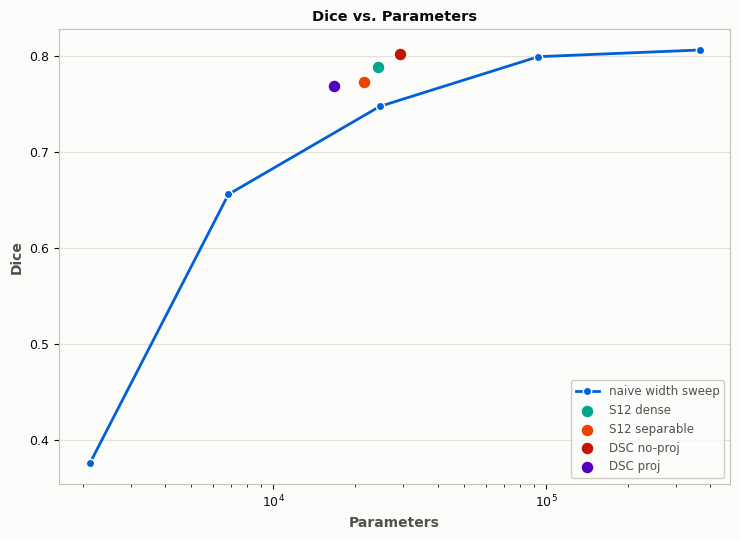

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_4\dice_vs_macs.png


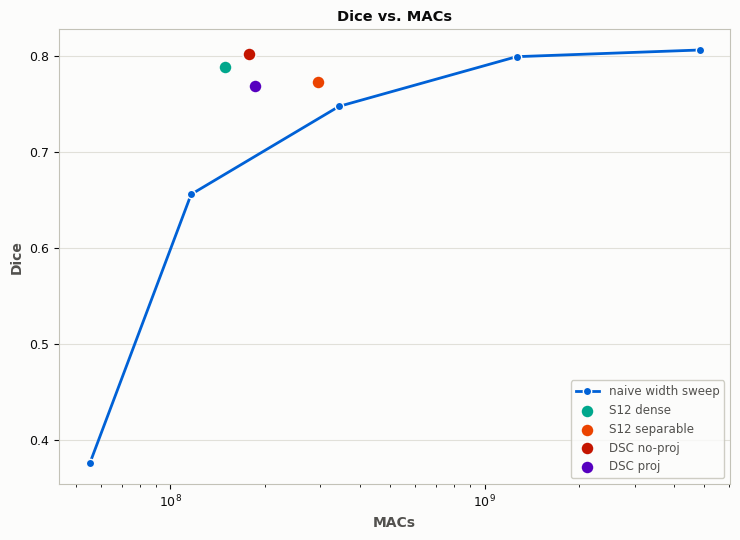

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_4\dice_vs_mem_elements.png


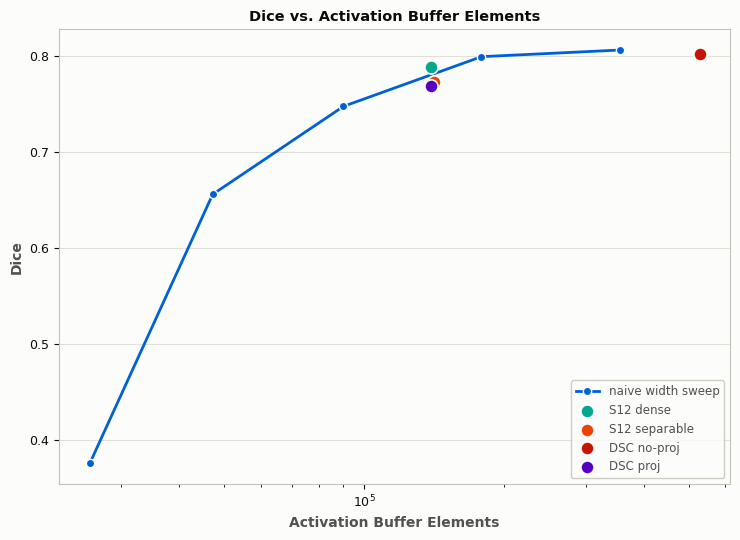

In [6]:
stage4 = ns.harvest("stage_4", df)
show_table(stage4)

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    s1 = stage1_relu.sort_values(metric)
    ax.plot(s1[metric], s1["dice"], color=ns.NAIVE_COLOR, linewidth=2, marker="o",
            markersize=6, markeredgecolor=ns.SURFACE, markeredgewidth=1, zorder=3,
            label="naive width sweep")
    for i, (_, row) in enumerate(stage4.iterrows()):
        color = ns.SERIES_COLORS[(i + 1) % len(ns.SERIES_COLORS)]
        ax.scatter([row[metric]], [row["dice"]], color=color, s=90, zorder=4,
                   edgecolor=ns.SURFACE, linewidth=1.2, label=row["label"])
    ns.style_title_and_labels(ax, f"Dice vs. {xlabel}", xlabel)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_4", f"dice_vs_{metric}.png")
    plt.show()


## Stage 5 -- Hardware-legality revisit: decoder swap

FINN also cannot efficiently fold bilinear resize. Stage 4's winner (S12
dense, ReLU already settled) is re-checked under nearest-neighbor and
learned-upsample decoders. No separable/DSC variant was ever re-run under
any alternate decoder in `results.csv` -- confirmed absent -- so only the
winner is checked here; the ranking among Stage 4's sub-variants isn't
re-litigated.

Excluded: `nnUNetTrainerENet_12_dense_relu_nearest_conv_upsample_256`
exists but uses `context_pattern=dense_dilation_half` (a distinct variant,
not a decoder-only rerun of the Stage 4 winner) and belongs to the
downstream 256-res hardware-build pipeline, not this controlled comparison.


,label,config_name,decoder_type,dice,params,macs,mem_elements
0,bilinear (Stage 4 winner),nnUNetTrainerENet_12_dense_relu,upsample_conv,0.787600,24261.0,148635648.0,139264.0
1,nearest-neighbor,nnUNetTrainerENet_12_dense_relu_nearest_conv_u...,nearest_conv_upsample,0.777919,26749.0,195821568.0,145408.0
2,learned upsample,nnUNetTrainerENet_12_dense_relu_learned_upsample,learned_upsample,0.767112,25349.0,169607168.0,139264.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_5\decoder_revalidation.png


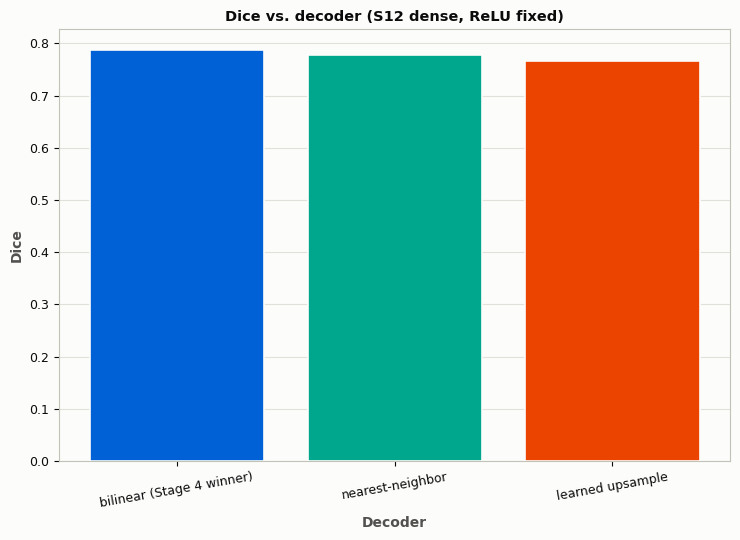

In [7]:
stage5 = ns.harvest("stage_5", df)
show_table(stage5, extra_cols=["decoder_type"])

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
ns.style_axes(ax)
colors = ns.SERIES_COLORS[: len(stage5)]
ax.bar(stage5["label"], stage5["dice"], color=colors, edgecolor=ns.SURFACE, linewidth=1.2, zorder=3)
ns.style_title_and_labels(ax, "Dice vs. decoder (S12 dense, ReLU fixed)", "Decoder")
ax.tick_params(axis="x", labelrotation=10)
fig.tight_layout()
save(fig, "stage_5", "decoder_revalidation.png")
plt.show()


## Stage 6 -- Post-selection probe: does stage3 (the dilated context stage) matter, at matched width?

Not part of how S12 dense was picked (Stages 1-5 already closed that question) -- a later, separate probe on S5.6's own PReLU/separable_dilated lineage (`5_6_separable_dense_dilation`, channels=4,16,32,16,4, bottlenecks=4,8,8,2,1, `context_pattern=dense_dilation`), asking whether the dilated context block can be collapsed into stage2 alone. Raw stage `26_s5_6_probe_family` ran 8 probes; half add a **d1 lead-in** (a distinct dilation-cycle shape, `context_pattern=dense_dilation_lead1`). This isolates the 4 non-lead-in probes (plain `dense_dilation`) plus their S5.6 reference, so only `bottlenecks_per_stage[2]` (stage3's block count) varies at each matched width -- lead-in variants are excluded so the stage3-removal effect isn't confounded with the cycle-shape change.

**Removing stage3 costs dice, and costs relatively MORE at narrower width:** at S5.6's own width (16,32,32,16,4), -0.065 dice (0.7985 -> 0.7334, -8.2% relative) for -37.8% params / -64.8% MACs / -44.2% activation-buffer elements. At the narrower w24 width (8,24,24,8,4), -0.079 dice (0.7567 -> 0.6776, **-10.4% relative, a larger hit**) for -40.6% params / -22.2% MACs / -45.0% mem elements. clDice and n_components move the same direction as dice in both pairs (fragmentation worsens when stage3 is removed) -- not a Dice-only artifact.

**Known gap:** `26_1_u8style` (the narrowest width probed) has no non-lead-in no-stage3 counterpart -- that pairing only exists as the lead-in variant `26_8_w24_no_stage3_d1leadin_halved`, excluded here. Included anyway as the narrowest stage3-present width point.

**Not converged:** none of these 5 rows are flagged `converged_flag=True` (all ~140-150 of a presumably longer schedule) -- read magnitudes as directional, not final.

,label,config_name,dice,params,macs,mem_elements
0,S5.6 base (stage3 present),nnUNetTrainerENet_5_6_separable_dense_dilation,0.798530,22513.0,303431680.0,141184.0
1,S5.6 width (stage3 removed),nnUNetTrainerENet_26_3_no_stage3,0.733439,14001.0,106692608.0,78784.0
2,w24 (stage3 present),nnUNetTrainerENet_26_5_w24,0.756656,12401.0,74530816.0,104096.0
3,w24 (stage3 removed),nnUNetTrainerENet_26_6_w24_no_stage3,0.677562,7361.0,58015744.0,57296.0
4,u8-style width (stage3 present),nnUNetTrainerENet_26_1_u8style,0.704687,6641.0,52690944.0,72640.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_6\dice_vs_params.png


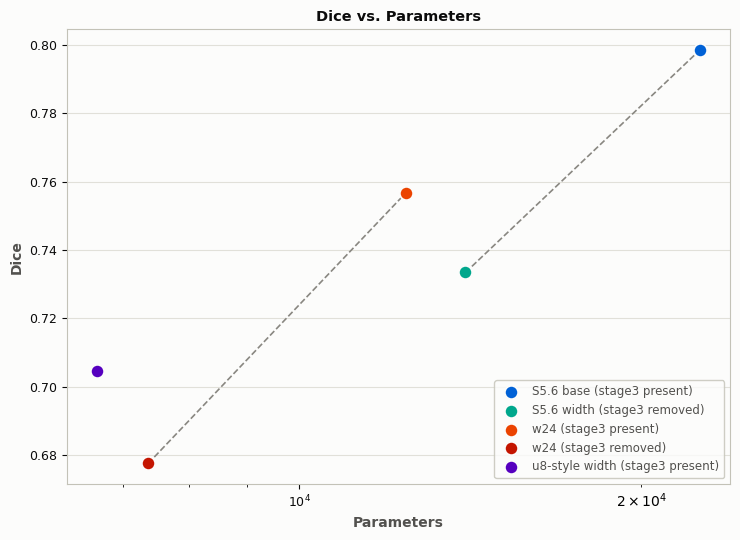

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_6\dice_vs_macs.png


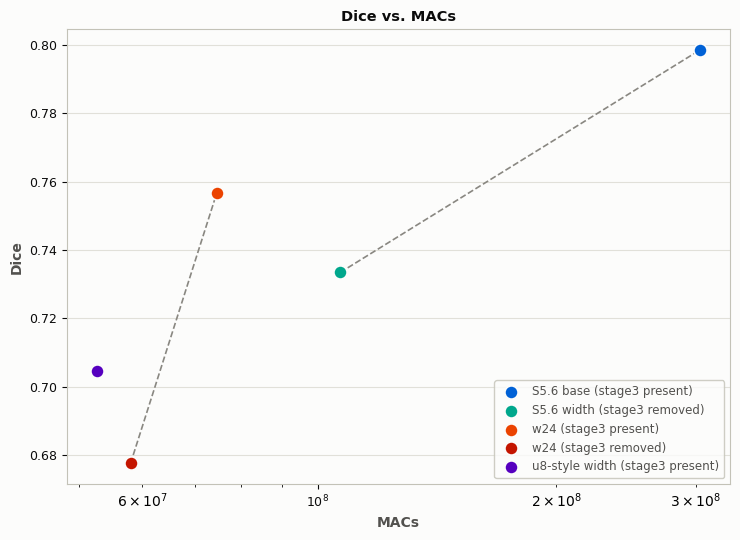

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_6\dice_vs_mem_elements.png


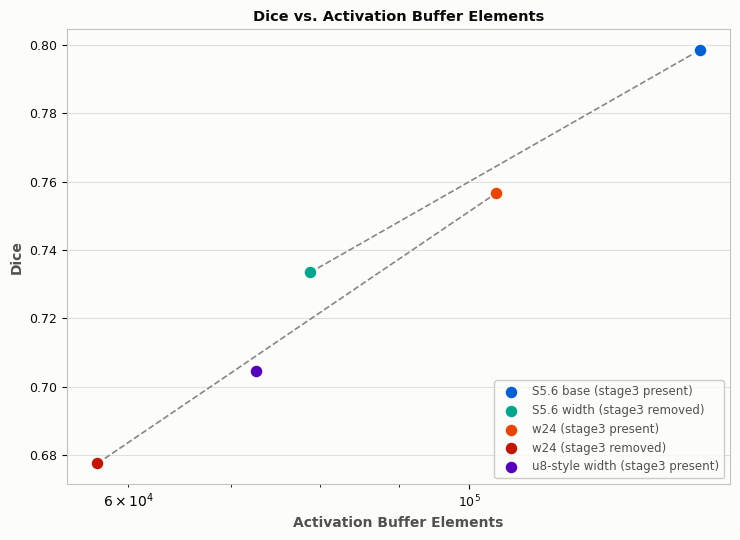

In [8]:
stage6 = ns.harvest("stage_6", df)
show_table(stage6)

PAIRS = [
    ("nnUNetTrainerENet_5_6_separable_dense_dilation", "nnUNetTrainerENet_26_3_no_stage3"),
    ("nnUNetTrainerENet_26_5_w24", "nnUNetTrainerENet_26_6_w24_no_stage3"),
]

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    idx = stage6.set_index("config_name")
    for with_name, without_name in PAIRS:
        pair = idx.loc[[with_name, without_name]].sort_values(metric)
        ax.plot(pair[metric], pair["dice"], color=ns.MUTED, linewidth=1.2,
                linestyle="--", zorder=2)
    for i, (_, row) in enumerate(stage6.iterrows()):
        color = ns.SERIES_COLORS[i % len(ns.SERIES_COLORS)]
        ax.scatter([row[metric]], [row["dice"]], color=color, s=90, zorder=4,
                   edgecolor=ns.SURFACE, linewidth=1.2, label=row["label"])
    ns.style_title_and_labels(ax, f"Dice vs. {xlabel}", xlabel)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_6", f"dice_vs_{metric}.png")
    plt.show()


## Stage 7 -- S12 dense family: width variation

Also post-selection: raw stage `12_dense_relu_width_sweep` re-runs S12 dense's own recipe (`context_pattern=dense_dilation`, ReLU, `upsample_conv`, `bottlenecks=4,8,8,2,1` fixed throughout -- only stage2/3/4 channel width moves) at 5 narrower widths below the Stage 4/5 winner's own 16,32,32,16,4, plus the winner itself (`nnUNetTrainerENet_12_dense_relu`) as the widest point. Unlike Stage 6, `bottlenecks_per_stage` never changes here -- this isolates width alone, holding stage3 and every other topology choice fixed at the Stage 4/5 winner's own settings.

,label,config_name,dice,params,macs,mem_elements
0,w4/8,nnUNetTrainerENet_12_dense_relu_w4_8,0.436460,2088.0,32243712.0,37888.0
1,w8/16,nnUNetTrainerENet_12_dense_relu_w8_16,0.699495,6745.0,55836672.0,71680.0
2,w8/20,nnUNetTrainerENet_12_dense_relu_w8_20,0.728495,9662.0,67473408.0,87168.0
3,w12/20,nnUNetTrainerENet_12_dense_relu_w12_20,0.746748,10597.0,80302080.0,89984.0
4,w12/24,nnUNetTrainerENet_12_dense_relu_w12_24,0.766843,14136.0,94633984.0,105472.0
5,w16/32 (Stage 4/5 winner),nnUNetTrainerENet_12_dense_relu,0.787600,24261.0,148635648.0,139264.0


Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_7\dice_vs_params.png


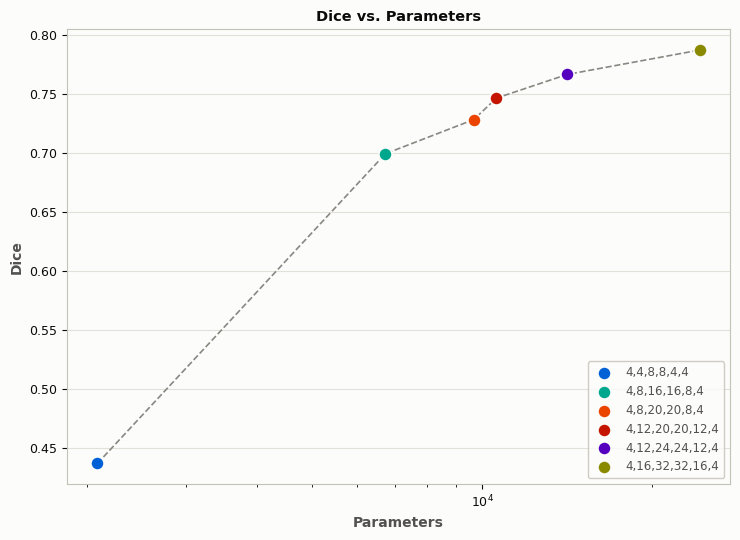

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_7\dice_vs_macs.png


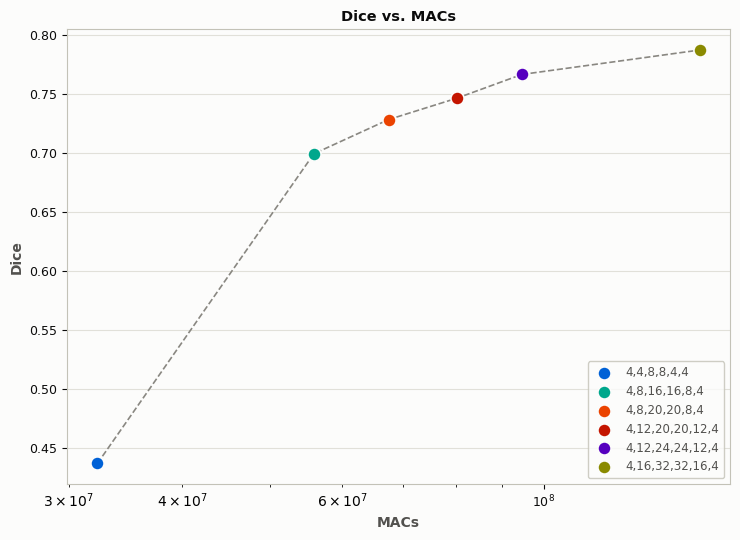

Wrote C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\report\model_search\stage_7\dice_vs_mem_elements.png


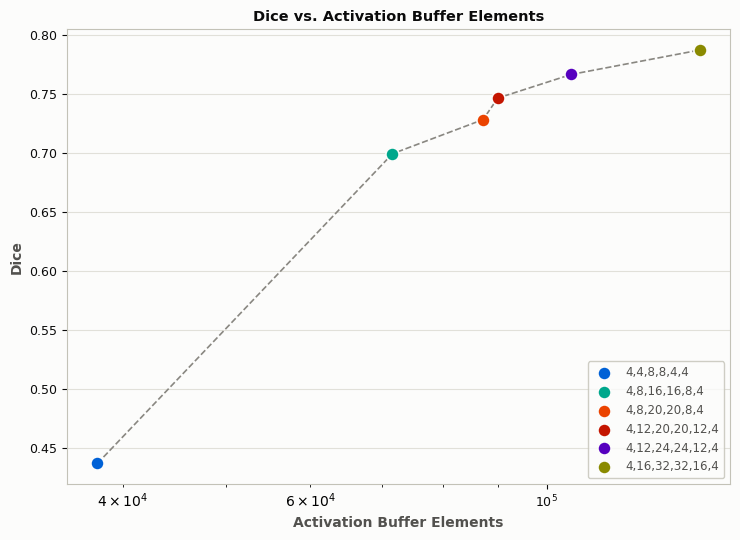

In [9]:
stage7 = ns.harvest("stage_7", df)
show_table(stage7)


def channel_str(row) -> str:
    return f"{int(row['f_i'])},{int(row['f1'])},{int(row['f2'])},{int(row['f3'])},{int(row['f4'])},{int(row['f5'])}"


for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    s = stage7.sort_values(metric)
    ax.plot(s[metric], s["dice"], color=ns.MUTED, linewidth=1.2, linestyle="--", zorder=2)
    for i, (_, row) in enumerate(stage7.iterrows()):
        color = ns.SERIES_COLORS[i % len(ns.SERIES_COLORS)]
        ax.scatter([row[metric]], [row["dice"]], color=color, s=90, zorder=4,
                   edgecolor=ns.SURFACE, linewidth=1.2, label=channel_str(row))
    ns.style_title_and_labels(ax, f"Dice vs. {xlabel}", xlabel)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_7", f"dice_vs_{metric}.png")
    plt.show()


## Excluded from this narrative

Excluded entirely from this narrative (not plotted anywhere):

- `3_transfer_original` -- warm-start-from-checkpoint experiment, orthogonal
  to this topology/activation/decoder search.
- Every reg_interleaved / separable-dense-dilation follow-on family: raw
  stages `5_arch_probe_pairs`, `6_dscnoprojdense_variants`,
  `7_reginterleaved_shape_variants`, `8_reginterleaved_isolation` (minus the
  one fullwidth DSC-no-proj row already used in Stage 4),
  `10_reginterleaved_separable_projected`, `13_*`, `15_*`..`22_*`, `23_*`,
  `25_*`, `27_*` -- none of these were carried forward to the final pick
  (S12 dense).
- Raw stage `26_s5_6_probe_family` -- mostly excluded (it's a post-selection
  probe on S5.6's own lineage, not part of how S12 dense was chosen), EXCEPT
  the 5 non-lead-in rows now isolated in Stage 6 (see its own excluded_note
  for exactly which `26_*` rows still aren't shown anywhere: the 4 d1-lead-in
  variants and the later `26_9`/`26_10`/pruned5 follow-ons).
- Every quantization/QAT/PTQ/HAWQ derivative row (blank `abbrev`,
  `joint_alpha*`/`uniform_int*`/`ptq*`/`qat*` suffixes) -- that's the later
  quantization chapter's material, not this NAS narrative.
